**Last update:** February 2026

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from multicam_tng.utils import (
    get_mah_interpolated,
    get_an_from_mpeak_mah,
    get_mpeak_from_mah,
)

from scipy.stats import spearmanr

In [108]:
from tqdm import tqdm

In [109]:
_file = "../../data/tng100_trees.npz"
with open(_file, "rb") as fp:
    trees_data = np.load(fp)
    matches_raw = trees_data["matches"]
    bdmo = trees_data["bdmo"]
    tdmo = trees_data["tdmo"]
    bbar = trees_data["bbar"]
    tbar = trees_data["tbar"]


In [110]:
matches_raw.shape, bdmo.shape, bbar.shape, tdmo.shape, tbar.shape

((153348,), (869229,), (153348,), (869229, 100), (153348, 100))

In [111]:
bbar.dtype, bdmo.dtype, tbar.dtype, tdmo.dtype

(dtype([('infall_snap', '<i4'), ('mpeak', '<f4'), ('mpeak_pre', '<f4'), ('is_err', '?'), ('vpeak', '<f4'), ('vpeak_pre', '<f4')]),
 dtype([('infall_snap', '<i4'), ('mpeak', '<f4'), ('mpeak_pre', '<f4'), ('is_err', '?'), ('vpeak', '<f4'), ('vpeak_pre', '<f4')]),
 dtype([('mdm', '<f4'), ('mvir', '<f4'), ('vmax', '<f4'), ('ok', '?'), ('is_sub', '?'), ('subfind_id', '<i8'), ('first_sub_idx', '<i8'), ('match', '<i8'), ('stellar_mass', '<f4')]),
 dtype([('mdm', '<f4'), ('mvir', '<f4'), ('vmax', '<f4'), ('ok', '?'), ('is_sub', '?'), ('subfind_id', '<i8'), ('first_sub_idx', '<i8'), ('match', '<i8')]))

In [112]:
metadata = pd.read_csv(
    "../../data/tng300-1-table.csv"
)  # this ist just metadata which sims share
redshift_snaps = metadata["Redshift"].values
scales = 1 / (1 + redshift_snaps)
scales

array([0.04750594, 0.06253909, 0.0770416 , 0.08347245, 0.09090909,
       0.09624639, 0.1       , 0.10582011, 0.11098779, 0.11627907,
       0.12135922, 0.12484395, 0.13351135, 0.14265335, 0.1459854 ,
       0.15313936, 0.16051364, 0.16666667, 0.17667845, 0.18416206,
       0.19305019, 0.1996008 , 0.21231423, 0.22271715, 0.23364486,
       0.24937656, 0.25641026, 0.26809651, 0.27932961, 0.29069767,
       0.30120482, 0.31152648, 0.32258065, 0.33333333, 0.34482759,
       0.35460993, 0.3649635 , 0.37453184, 0.38461538, 0.39525692,
       0.4       , 0.41493776, 0.42372881, 0.43478261, 0.44444444,
       0.45248869, 0.46511628, 0.47393365, 0.48309179, 0.49019608,
       0.5       , 0.51282051, 0.52083333, 0.52910053, 0.54054054,
       0.54945055, 0.55865922, 0.56818182, 0.57803468, 0.58823529,
       0.5952381 , 0.6097561 , 0.61728395, 0.625     , 0.63291139,
       0.64516129, 0.65789474, 0.66666667, 0.67567568, 0.68493151,
       0.69444444, 0.70422535, 0.71428571, 0.72463768, 0.73529

# Matches

In [113]:
# repetitions
print(len(set([m.item() for m in matches_raw])), len(matches_raw))

# repetitions all come from "-1" placeholder element
print(sum(matches_raw == -1) + len(set([m.item() for m in matches_raw])) - 1)

# indices range
matches_raw.max(), bdmo.shape

143016 153348
153348


(np.int64(869228), (869229,))

In [114]:
# get inverse
mask = matches_raw != -1
index_bar = np.arange(len(bbar))
matches_dmo_raw = np.full(len(bdmo), fill_value=-1)
matches_dmo_raw[matches_raw[mask]] = index_bar[mask]
# mask2 = np.isin(np.arange(len(bdmo)), matches[mask1])
# assert sum(mask1) == sum(mask2)
# index_bar2 = index_bar[mask1]
# sort_mask = np.argsort(matches[mask1])


In [115]:
# sanity check
for ii, x in enumerate(matches_raw):
    if x != -1:
        assert ii == matches_dmo_raw[x]


In [116]:
matches_raw.shape, matches_dmo_raw.shape

((153348,), (869229,))

# DMO

In [117]:
mask = (tdmo["ok"][:, -1]) & (tdmo["mdm"][:, -1] > 0) & (~bdmo["is_err"])
sum(mask) / len(mask), len(mask)

(np.float64(0.6139624885962157), 869229)

In [122]:
assert np.all(tdmo["subfind_id"][:, -1][mask] >= 0)

In [123]:
# percentage of bad trees that are not "OK"
# this flag captures all cases we care about
sum(mask), sum(tdmo["ok"][:, -1])
assert np.all(mask == tdmo["ok"][:, -1])

In [124]:
mah = get_mah_interpolated(tdmo["mdm"][mask])

100%|██████████| 533674/533674 [00:33<00:00, 16080.08it/s]


In [15]:
mpeak_mah = get_mpeak_from_mah(np.log10(mah))
mpeak_mah.shape

(533674, 100)

In [16]:
a12 = get_an_from_mpeak_mah(mpeak_mah, scales=scales, ns=np.array([0.5]))[:, 0]
a12.shape

(533674,)

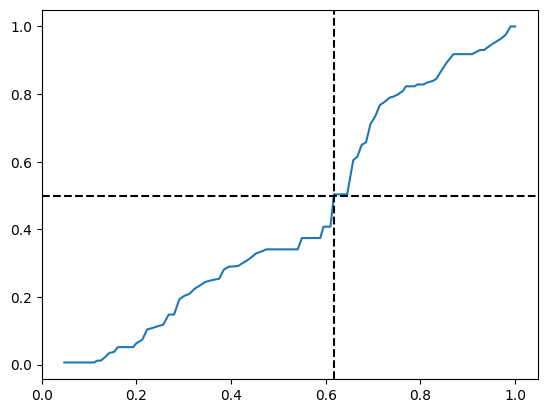

In [18]:
# example to sanity check
idx = np.random.randint(mpeak_mah.shape[0])
mah_ex = mpeak_mah[idx]

plt.plot(scales, mah_ex)
plt.axvline(a12[idx], ls="--", c="k")
plt.axhline(0.5, ls="--", c="k")

In [19]:
np.unique(a12).shape[0], len(a12)  # a lot more unique values

(514803, 533674)

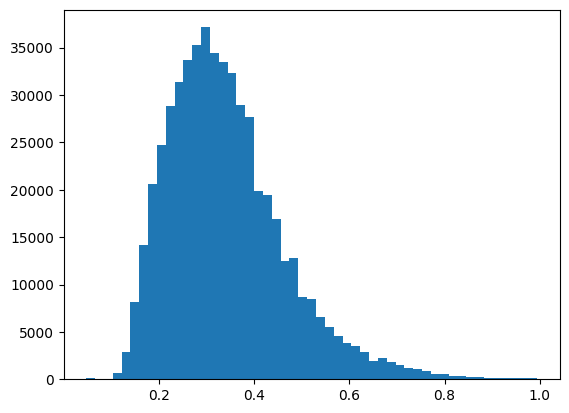

In [21]:
plt.hist(a12, bins=51);

In [ ]:
# match id
match_id = []
for x in matches_dmo_raw:
    if x != -1:
        match_id.append(tbar["subfind_id"][:, -1][x])
    else:
        match_id.append(np.nan)

match_id = np.array(match_id, dtype=int)
match_id.shape

(869229,)

In [96]:
matches_dmo_raw

array([    0,    -1,    40, ...,    -1,    -1, 54433], shape=(869229,))

In [23]:
out = {
    "subfind_id": tdmo["subfind_id"][:, -1][mask],
    "vpeak_pre": bdmo["vpeak_pre"][mask],
    "vpeak": bdmo["vpeak"][mask],
    "mpeak_pre": bdmo["mpeak_pre"][mask],
    "mpeak": bdmo["mpeak"][mask],
    "is_sub": tdmo["is_sub"][:, -1][mask],
    "match_id": match_id[mask],
    "mah": mah,
    "mpeak_mah": mpeak_mah,
    "a12": a12,
}

with open("../../data/out-trees-tng100-dmo.npz", "wb") as fp:
    np.savez(fp, **out)

# Baryons

In [24]:
mask = (tbar["ok"][:, -1]) & (tbar["mdm"][:, -1] > 0) & (~bbar["is_err"])
sum(mask) / len(mask), len(mask)

(np.float64(0.6614432532540365), 153348)

In [ ]:
assert np.all(tbar["subfind_id"][:, -1][mask] >= 0)

In [25]:
mah = get_mah_interpolated(tbar["mdm"][mask])

100%|██████████| 101431/101431 [00:06<00:00, 15868.88it/s]


In [26]:
# get mpeak
mpeak_mah = get_mpeak_from_mah(np.log10(mah))
mpeak_mah.shape

(101431, 100)

In [27]:
a12 = get_an_from_mpeak_mah(mpeak_mah, scales=scales, ns=np.array([0.5]))[:, 0]
a12.shape

(101431,)

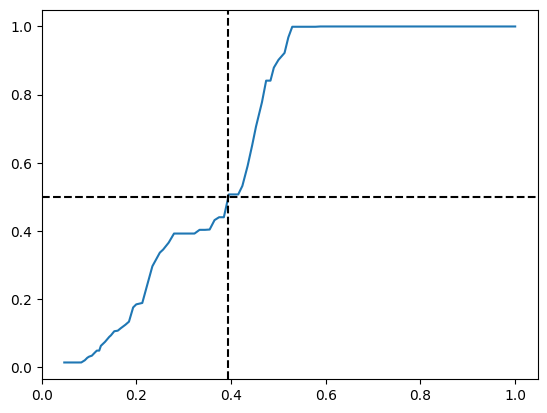

In [87]:
# example to sanity check
idx = np.random.randint(mpeak_mah.shape[0])
mah_ex = mpeak_mah[idx]

plt.plot(scales, mah_ex)
plt.axvline(a12[idx], ls="--", c="k")
plt.axhline(0.5, ls="--", c="k")

In [ ]:
# match id
match_id = []
for x in matches_raw:
    if x != -1:
        match_id.append(tdmo["subfind_id"][:, -1][x])
    else:
        match_id.append(np.nan)

match_id = np.array(match_id, dtype=int)
match_id.shape

(153348,)

In [90]:
out = {
    "subfind_id": tbar["subfind_id"][:, -1][mask],
    "vpeak": bbar["vpeak"][mask],
    "vpeak_pre": bbar["vpeak_pre"][mask],
    "is_sub": tbar["is_sub"][:, -1][mask],
    "mpeak_pre": bbar["mpeak_pre"][mask],
    "mpeak": bbar["mpeak"][mask],
    "stellar_mass": tbar["stellar_mass"][:, -1][mask],
    "match_id": match_id[mask],
    "mpeak_mah": mpeak_mah,
    "a12": a12,
}

with open("../../data/out-trees-tng100-bar.npz", "wb") as fp:
    np.savez(fp, **out)

In [98]:
tdmo["subfind_id"][:, -1]

array([  59551,      -1,      -1, ..., 1246896, 1363866, 1335215],
      shape=(869229,))

In [97]:
match_id[mask]

array([ 5.955100e+04, -1.000000e+00,  5.955400e+04, ...,  1.158433e+06,
        1.153091e+06,  1.162925e+06], shape=(101431,))

## How to get matched in order quantities


In [ ]:
# mask has already been applied

out_bar = np.load("../../data/out-trees-tng100-bar.npz")
out_dmo = np.load("../../data/out-trees-tng100-dmo.npz")


out_bar["subfind_id"].shape, out_dmo["subfind_id"].shape

((101431,), (533674,))

In [ ]:
arr = out_bar["subfind_id"]


array([ 31342,  31346,  31347, ..., 865091, 879151, 876322],
      shape=(101431,))

In [127]:
# sanity check
match_dmo = out_dmo["match_id"]
match_bar = out_bar["match_id"]


for ii, x in tqdm(enumerate(match_dmo), total=match_dmo.shape[0]):
    if not np.isnan(x) and x != -1:
        dmo_id = out_dmo["subfind_id"][ii]
        bar_index = np.where(out_bar["subfind_id"] == x)[0][0]
        match_bar_id = out_bar["match_id"][bar_index]
        assert match_bar_id == dmo_id

100%|██████████| 533674/533674 [01:26<00:00, 6164.01it/s]  


In [128]:
for ii, x in tqdm(enumerate(match_bar), total=match_bar.shape[0]):
    if not np.isnan(x) and x != -1:
        bar_id = out_bar["subfind_id"][ii]
        dmo_index = np.where(out_dmo["subfind_id"] == x)[0][0]
        match_bar_id = out_dmo["match_id"][dmo_index]
        assert match_bar_id == bar_id

100%|██████████| 101431/101431 [02:51<00:00, 589.99it/s]


In [136]:
# how to match baryons to dmo and get correct order.
mask_bar = (out_bar["match_id"] != -1) & (~np.isnan(out_bar["match_id"]))
mask_dmo = (out_dmo["match_id"] != -1) & (~np.isnan(out_dmo["match_id"]))

# one more sanity
sort_bar = np.argsort(out_bar["match_id"][mask_bar])
subfind_id_bar = out_bar["subfind_id"][mask_bar][sort_bar]

sort_dmo = np.argsort(out_dmo["subfind_id"][mask_dmo])
match_id_dmo = out_dmo["match_id"][mask_dmo][sort_dmo]
assert np.all(subfind_id_bar == match_id_dmo)

In [138]:
x = out_dmo["mpeak"][mask_dmo][sort_dmo]
y = out_bar["mpeak"][mask_bar][sort_bar]
x.shape, y.shape

((88516,), (88516,))

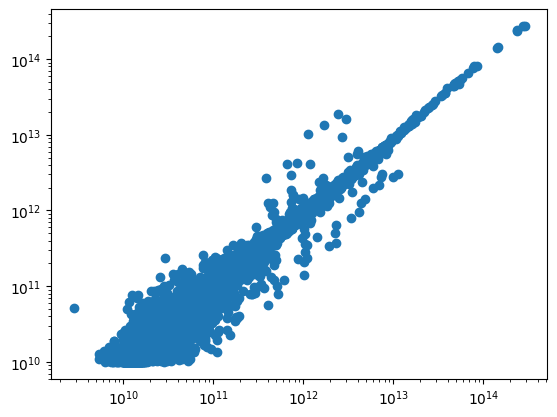

In [139]:
plt.loglog(x, y, "o")

In [140]:
spearmanr(x, y)

SignificanceResult(statistic=np.float64(0.985033129649648), pvalue=np.float64(0.0))

In [142]:
# how many in mpeak bin and mtached? (dmo)
cond = (x > 10**11) & (x < 10**12)
sum(cond)

np.int64(9575)

In [ ]:
# how does it compare to unmatched things in the bin?
_mpeak = out_dmo["mpeak"]
_cond = (_mpeak > 10**11) & (_mpeak < 10**12)
sum(_cond)

# we lose like ~30%

np.int64(14181)